# ver5 환자 단위 Alzheimer 조기 탐지 - Partial Fine-Tuning

이 버전은 ver4의 환자 단위 split과 조기 탐지 task를 그대로 유지하면서 fine-tuning 범위만 안정화합니다.

기본 실험:

```text
NonDemented vs VeryMildDemented
```

ver4와 비교할 핵심 변경점:
- Epoch 1~3: EfficientNet backbone 전체를 동결하고 classifier만 학습
- Epoch 4 이후: `features[7]`, `features[8]`, classifier만 부분 fine-tuning
- 전체 backbone은 풀지 않음
- head learning rate와 backbone learning rate를 낮춤
- partial fine-tuning 시작 후 validation 환자 AUROC 기반 early stopping 적용
- 환자 split manifest와 test 환자는 ver4와 동일하게 유지

## 1. 환경 점검 및 Seed 고정

In [1]:
import os
import re
import sys
import time
import random
from pathlib import Path
from collections import Counter, defaultdict
from contextlib import contextmanager

import numpy as np
import pandas as pd
import torch

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python: {sys.executable}")
print(f"torch: {torch.__version__}")
print(f"CUDA runtime: {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"device: {device}")

Python: C:\Users\user\anaconda3\envs\alzheimer\python.exe
torch: 2.12.0.dev20260408+cu128
CUDA runtime: 12.8
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
device: cuda


## 2. 실험 Config

In [2]:
DATA_ROOT = Path(r"C:\Users\user\Desktop\alzheimer_dataset\Data")
OUTPUT_DIR = Path(r"C:\Users\user\alzheimer\patient_level_experiments")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["NonDemented", "VeryMildDemented", "MildDemented", "ModerateDemented"]

# 가능한 task:
# "non_vs_verymild"  : 정상 vs 매우 경도 치매, 기본 조기 탐지 모델
# "non_vs_mild"      : 정상 vs 경도 치매
# "non_vs_demented"  : 정상 vs VeryMild+Mild+Moderate
# "verymild_vs_advanced": VeryMild vs Mild+Moderate
TASK_NAME = "non_vs_verymild"

TASK_CONFIGS = {
    "non_vs_verymild": {
        "negative_classes": ["NonDemented"],
        "positive_classes": ["VeryMildDemented"],
        "negative_name": "NonDemented",
        "positive_name": "VeryMildDemented",
    },
    "non_vs_mild": {
        "negative_classes": ["NonDemented"],
        "positive_classes": ["MildDemented"],
        "negative_name": "NonDemented",
        "positive_name": "MildDemented",
    },
    "non_vs_demented": {
        "negative_classes": ["NonDemented"],
        "positive_classes": ["VeryMildDemented", "MildDemented", "ModerateDemented"],
        "negative_name": "NonDemented",
        "positive_name": "Demented",
    },
    "verymild_vs_advanced": {
        "negative_classes": ["VeryMildDemented"],
        "positive_classes": ["MildDemented", "ModerateDemented"],
        "negative_name": "VeryMildDemented",
        "positive_name": "MildOrModerate",
    },
}
assert TASK_NAME in TASK_CONFIGS
TASK = TASK_CONFIGS[TASK_NAME]

# 환자 단위 split 비율
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9

# Train augmentation. val/test에는 적용하지 않습니다.
TRAIN_AUG_MODE = "sepaug_4n"  # "original", "sepaug_3n", "sepaug_4n"
ROTATION_DEGREES = 10
SHIFT_TRANSLATE = (0.05, 0.05)
ZOOM_SCALE = (0.9, 1.1)
DETERMINISTIC_AUGMENTATION = True

# CNN 설정
CNN_MODEL_NAME = "efficientnet_b0"
USE_PRETRAINED = True
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = True
PERSISTENT_WORKERS = NUM_WORKERS > 0
EPOCHS = 8
FREEZE_BACKBONE_EPOCHS = 3
HEAD_LR = 3e-4
BACKBONE_LR = 3e-6
WEIGHT_DECAY = 1e-4
USE_AMP = True
BALANCE_STRATEGY = "class_weight_sqrt"
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_MIN_DELTA = 1e-4

print(f"TASK_NAME: {TASK_NAME}")
print(f"negative: {TASK['negative_name']}")
print(f"positive: {TASK['positive_name']}")
print(f"TRAIN_AUG_MODE: {TRAIN_AUG_MODE}")

TASK_NAME: non_vs_verymild
negative: NonDemented
positive: VeryMildDemented
TRAIN_AUG_MODE: sepaug_4n


## 3. 원본 Dataset Manifest 생성

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
PATIENT_PATTERN = re.compile(r"^(OAS1_\d+)", re.IGNORECASE)
SCAN_PATTERN = re.compile(r"^(OAS1_\d+_MR\d+)", re.IGNORECASE)

rows = []
for class_name in CLASS_NAMES:
    class_dir = DATA_ROOT / class_name
    assert class_dir.exists(), f"Class directory not found: {class_dir}"
    for image_path in sorted(class_dir.iterdir()):
        if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        patient_match = PATIENT_PATTERN.match(image_path.name)
        scan_match = SCAN_PATTERN.match(image_path.name)
        assert patient_match, f"환자 ID를 파싱할 수 없습니다: {image_path.name}"
        rows.append({
            "image_path": str(image_path),
            "class_name": class_name,
            "patient_id": patient_match.group(1).upper(),
            "scan_id": scan_match.group(1).upper() if scan_match else patient_match.group(1).upper(),
        })

manifest = pd.DataFrame(rows)
assert not manifest.empty

# 한 환자가 서로 다른 class label을 갖는지 검사합니다.
patient_label_counts = manifest.groupby("patient_id")["class_name"].nunique()
assert patient_label_counts.max() == 1, "동일 환자에게 서로 다른 class label이 존재합니다."

manifest_path = OUTPUT_DIR / "all_images_patient_manifest.csv"
manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")

print(f"전체 이미지 수: {len(manifest):,}")
print(f"전체 환자 수: {manifest['patient_id'].nunique():,}")
print(f"manifest: {manifest_path}")
print("\n[클래스별 이미지/환자 수]")
for class_name in CLASS_NAMES:
    subset = manifest[manifest["class_name"] == class_name]
    print(f"{class_name:20s}: images={len(subset):6,}, patients={subset['patient_id'].nunique():3,}")

전체 이미지 수: 86,437
전체 환자 수: 347
manifest: C:\Users\user\alzheimer\patient_level_experiments\all_images_patient_manifest.csv

[클래스별 이미지/환자 수]
NonDemented         : images=67,222, patients=266
VeryMildDemented    : images=13,725, patients= 58
MildDemented        : images= 5,002, patients= 21
ModerateDemented    : images=   488, patients=  2


## 4. Task 선택 및 환자 단위 Train/Validation/Test Split

In [4]:
from sklearn.model_selection import train_test_split

negative_set = set(TASK["negative_classes"])
positive_set = set(TASK["positive_classes"])
selected_classes = negative_set | positive_set

task_manifest = manifest[manifest["class_name"].isin(selected_classes)].copy()
task_manifest["target"] = task_manifest["class_name"].apply(lambda x: 0 if x in negative_set else 1)

patient_table = (
    task_manifest.groupby("patient_id", as_index=False)
    .agg(target=("target", "first"), class_name=("class_name", "first"), image_count=("image_path", "count"))
)

# 환자 한 명이 target 두 개를 갖지 않는지 재검사합니다.
assert task_manifest.groupby("patient_id")["target"].nunique().max() == 1

train_patients, temp_patients = train_test_split(
    patient_table,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=patient_table["target"],
)

relative_test_ratio = TEST_RATIO / (VAL_RATIO + TEST_RATIO)
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=relative_test_ratio,
    random_state=SEED,
    stratify=temp_patients["target"],
)

split_map = {}
split_map.update({pid: "train" for pid in train_patients["patient_id"]})
split_map.update({pid: "val" for pid in val_patients["patient_id"]})
split_map.update({pid: "test" for pid in test_patients["patient_id"]})
task_manifest["split"] = task_manifest["patient_id"].map(split_map)

train_ids = set(train_patients["patient_id"])
val_ids = set(val_patients["patient_id"])
test_ids = set(test_patients["patient_id"])

# Leakage 방지 assertions
assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)
assert task_manifest["split"].notna().all()

split_manifest_path = OUTPUT_DIR / f"{TASK_NAME}_patient_split_seed{SEED}.csv"
task_manifest.to_csv(split_manifest_path, index=False, encoding="utf-8-sig")

print(f"split manifest: {split_manifest_path}")
for split_name, patient_df in [("train", train_patients), ("val", val_patients), ("test", test_patients)]:
    counts = patient_df["target"].value_counts().sort_index().to_dict()
    image_count = len(task_manifest[task_manifest["split"] == split_name])
    print(
        f"{split_name:5s}: patients={len(patient_df):3d}, images={image_count:6d}, "
        f"negative={counts.get(0, 0):3d}, positive={counts.get(1, 0):3d}"
    )

print("\nLeakage check: PASS")
print(f"train ∩ val : {len(train_ids & val_ids)}")
print(f"train ∩ test: {len(train_ids & test_ids)}")
print(f"val ∩ test  : {len(val_ids & test_ids)}")

split manifest: C:\Users\user\alzheimer\patient_level_experiments\non_vs_verymild_patient_split_seed42.csv
train: patients=226, images= 55876, negative=186, positive= 40
val  : patients= 49, images= 12566, negative= 40, positive=  9
test : patients= 49, images= 12505, negative= 40, positive=  9

Leakage check: PASS
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


## 5. EfficientNet-B0 및 Dataset 정의

EfficientNet-B0는 ImageNet pretrained weight를 사용합니다. train 환자에게만 separate augmentation을 적용하며 val/test는 원본 preprocess만 적용합니다.

In [5]:
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset
from torchvision import models, transforms

weights = models.EfficientNet_B0_Weights.DEFAULT if USE_PRETRAINED else None
model = models.efficientnet_b0(weights=weights)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 2)
preprocess = weights.transforms() if weights is not None else models.EfficientNet_B0_Weights.DEFAULT.transforms()
model = model.to(device)

@contextmanager
def temporary_seed(seed):
    py_state = random.getstate()
    np_state = np.random.get_state()
    torch_state = torch.random.get_rng_state()
    try:
        random.seed(seed)
        np.random.seed(seed % (2**32 - 1))
        torch.manual_seed(seed)
        yield
    finally:
        random.setstate(py_state)
        np.random.set_state(np_state)
        torch.random.set_rng_state(torch_state)

class PatientSliceDataset(Dataset):
    def __init__(self, dataframe, preprocess, aug_mode="original", deterministic=True, seed=42):
        self.df = dataframe.reset_index(drop=True).copy()
        self.preprocess = preprocess
        self.aug_mode = aug_mode
        self.deterministic = deterministic
        self.seed = seed

        if aug_mode == "original":
            self.output_types = ["original"]
        elif aug_mode == "sepaug_3n":
            self.output_types = ["rotation", "shift", "zoom"]
        elif aug_mode == "sepaug_4n":
            self.output_types = ["original", "rotation", "shift", "zoom"]
        else:
            raise ValueError(aug_mode)

        self.rotation = transforms.RandomRotation(ROTATION_DEGREES)
        self.shift = transforms.RandomAffine(degrees=0, translate=SHIFT_TRANSLATE)
        self.zoom = transforms.RandomAffine(degrees=0, scale=ZOOM_SCALE)

    def __len__(self):
        return len(self.df) * len(self.output_types)

    def _augment(self, image, aug_type):
        if aug_type == "original":
            return image
        if aug_type == "rotation":
            return self.rotation(image)
        if aug_type == "shift":
            return self.shift(image)
        if aug_type == "zoom":
            return self.zoom(image)
        raise ValueError(aug_type)

    def __getitem__(self, idx):
        multiplier = len(self.output_types)
        base_idx = idx // multiplier
        aug_idx = idx % multiplier
        row = self.df.iloc[base_idx]
        aug_type = self.output_types[aug_idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.deterministic:
            with temporary_seed(self.seed + base_idx * 1009 + aug_idx * 9176):
                image = self._augment(image, aug_type)
        else:
            image = self._augment(image, aug_type)
        image = self.preprocess(image)

        return image, torch.tensor(int(row["target"]), dtype=torch.long), row["patient_id"]

train_df = task_manifest[task_manifest["split"] == "train"].copy()
val_df = task_manifest[task_manifest["split"] == "val"].copy()
test_df = task_manifest[task_manifest["split"] == "test"].copy()

train_dataset = PatientSliceDataset(
    train_df, preprocess, aug_mode=TRAIN_AUG_MODE,
    deterministic=DETERMINISTIC_AUGMENTATION, seed=SEED,
)
val_dataset = PatientSliceDataset(val_df, preprocess, aug_mode="original", deterministic=True, seed=SEED)
test_dataset = PatientSliceDataset(test_df, preprocess, aug_mode="original", deterministic=True, seed=SEED)

print(f"model: {model.__class__.__name__}")
print(f"train dataset: {len(train_dataset):,}")
print(f"val dataset  : {len(val_dataset):,}")
print(f"test dataset : {len(test_dataset):,}")

model: EfficientNet
train dataset: 223,504
val dataset  : 12,566
test dataset : 12,505


## 6. DataLoader 및 Class Weight

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)

# 환자 수 기준 class weight를 사용합니다. slice 수 기준이 아닙니다.
patient_target_counts = train_patients["target"].value_counts().sort_index()
counts = np.array([patient_target_counts.get(0, 0), patient_target_counts.get(1, 0)], dtype=np.float64)

if BALANCE_STRATEGY == "class_weight_sqrt":
    class_weights_np = 1.0 / np.sqrt(np.maximum(counts, 1))
    class_weights_np /= class_weights_np.mean()
    class_weight = torch.tensor(class_weights_np, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)
elif BALANCE_STRATEGY == "none":
    class_weight = None
    criterion = nn.CrossEntropyLoss()
else:
    raise ValueError(BALANCE_STRATEGY)

print(f"환자 기준 train class count: {counts.astype(int).tolist()}")
print(f"class_weight: {None if class_weight is None else class_weight.tolist()}")
print(f"train batches: {len(train_loader):,}")

환자 기준 train class count: [186, 40]
class_weight: [0.6336361169815063, 1.3663638830184937]
train batches: 6,985


## 7. CNN 학습 및 환자 단위 Validation

In [7]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score

def freeze_backbone_train_head():
    """EfficientNet feature extractor를 모두 동결하고 classifier만 학습합니다."""
    for param in model.parameters():
        param.requires_grad = False
    for param in model.classifier.parameters():
        param.requires_grad = True

def unfreeze_last_stages():
    """마지막 MBConv stage, head convolution, classifier만 부분 fine-tuning합니다."""
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[7].parameters():
        param.requires_grad = True
    for param in model.features[8].parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

def make_optimizer():
    head_ids = {id(p) for p in model.classifier.parameters()}
    head_params, backbone_params = [], []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        if id(param) in head_ids:
            head_params.append(param)
        else:
            backbone_params.append(param)

    groups = []
    if backbone_params:
        groups.append({"params": backbone_params, "lr": BACKBONE_LR})
    groups.append({"params": head_params, "lr": HEAD_LR})
    return torch.optim.AdamW(groups, weight_decay=WEIGHT_DECAY)

def count_trainable_parameters():
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def aggregate_patient_predictions(patient_ids, labels, probabilities):
    grouped_probs = defaultdict(list)
    grouped_labels = {}
    for patient_id, label, prob in zip(patient_ids, labels, probabilities):
        grouped_probs[patient_id].append(prob)
        grouped_labels[patient_id] = label
    ordered_ids = sorted(grouped_probs)
    patient_probs = np.array([np.mean(grouped_probs[pid]) for pid in ordered_ids])
    patient_labels = np.array([grouped_labels[pid] for pid in ordered_ids])
    patient_preds = (patient_probs >= 0.5).astype(int)
    return ordered_ids, patient_labels, patient_probs, patient_preds

def evaluate_patient_level(loader):
    model.eval()
    patient_ids, labels_all, probs_all = [], [], []
    with torch.inference_mode():
        for images, labels, batch_patient_ids in loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
                logits = model(images)
            probs = logits.softmax(dim=1)[:, 1].cpu().numpy()
            patient_ids.extend(list(batch_patient_ids))
            labels_all.extend(labels.numpy().tolist())
            probs_all.extend(probs.tolist())

    ids, y_true, y_prob, y_pred = aggregate_patient_predictions(patient_ids, labels_all, probs_all)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "auroc": roc_auc_score(y_true, y_prob),
        "auprc": average_precision_score(y_true, y_prob),
    }
    return metrics, ids, y_true, y_prob, y_pred

freeze_backbone_train_head()
optimizer = make_optimizer()
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and torch.cuda.is_available()))

best_val_auroc = -1.0
best_epoch = 0
best_state = None
epochs_without_improvement = 0
partial_finetune_started = False
history = []

print(f"초기 학습 가능 parameter 수: {count_trainable_parameters():,}")
print(f"Epoch 1~{FREEZE_BACKBONE_EPOCHS}: classifier만 학습")
print(
    f"Epoch {FREEZE_BACKBONE_EPOCHS + 1} 이후: "
    "features[7], features[8], classifier만 partial fine-tuning"
)

for epoch in range(1, EPOCHS + 1):
    if epoch == FREEZE_BACKBONE_EPOCHS + 1:
        unfreeze_last_stages()
        optimizer = make_optimizer()
        partial_finetune_started = True
        epochs_without_improvement = 0
        print("Partial fine-tuning 시작")
        print(f"학습 가능 parameter 수: {count_trainable_parameters():,}")
        print(f"BACKBONE_LR={BACKBONE_LR}, HEAD_LR={HEAD_LR}")

    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for images, labels, patient_ids in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=(USE_AMP and torch.cuda.is_available())):
            logits = model(images)
            loss = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

    train_loss = loss_sum / max(total, 1)
    train_slice_acc = correct / max(total, 1)
    val_metrics, *_ = evaluate_patient_level(val_loader)

    improved = val_metrics["auroc"] > best_val_auroc + EARLY_STOPPING_MIN_DELTA
    if improved:
        best_val_auroc = val_metrics["auroc"]
        best_epoch = epoch
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    elif partial_finetune_started:
        epochs_without_improvement += 1

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_slice_acc": train_slice_acc,
        **val_metrics,
    })
    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train loss {train_loss:.4f} slice acc {train_slice_acc:.4f} | "
        f"val patient acc {val_metrics['accuracy']:.4f} F1 {val_metrics['f1']:.4f} "
        f"AUROC {val_metrics['auroc']:.4f} AUPRC {val_metrics['auprc']:.4f} | "
        f"early_stop {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
    )

    if partial_finetune_started and epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: validation AUROC가 {EARLY_STOPPING_PATIENCE} epoch 동안 개선되지 않았습니다.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model = model.to(device)

print(f"Best epoch: {best_epoch}")
print(f"Best validation patient AUROC: {best_val_auroc:.4f}")

초기 학습 가능 parameter 수: 2,562
Epoch 1~3: classifier만 학습
Epoch 4 이후: features[7], features[8], classifier만 partial fine-tuning
Epoch 01/8 | train loss 0.4746 slice acc 0.8205 | val patient acc 0.8163 F1 0.4706 AUROC 0.8833 AUPRC 0.6359 | early_stop 0/2
Epoch 02/8 | train loss 0.4550 slice acc 0.8245 | val patient acc 0.8163 F1 0.4706 AUROC 0.8806 AUPRC 0.6560 | early_stop 0/2
Epoch 03/8 | train loss 0.4540 slice acc 0.8250 | val patient acc 0.7959 F1 0.3750 AUROC 0.8806 AUPRC 0.6296 | early_stop 0/2
Partial fine-tuning 시작
학습 가능 parameter 수: 1,131,954
BACKBONE_LR=3e-06, HEAD_LR=0.0003
Epoch 04/8 | train loss 0.4236 slice acc 0.8363 | val patient acc 0.8163 F1 0.5263 AUROC 0.8806 AUPRC 0.6352 | early_stop 1/2
Epoch 05/8 | train loss 0.3801 slice acc 0.8512 | val patient acc 0.8367 F1 0.5556 AUROC 0.9000 AUPRC 0.6923 | early_stop 0/2
Epoch 06/8 | train loss 0.3487 slice acc 0.8628 | val patient acc 0.8367 F1 0.5556 AUROC 0.8972 AUPRC 0.6927 | early_stop 1/2
Epoch 07/8 | train loss 0.3276 sli

## 8. 최종 Test 평가: 환자 단위

TASK: non_vs_verymild
Test patients: 49
Accuracy   : 0.6939
F1         : 0.2857
Macro F1   : 0.5455
AUROC      : 0.8028
AUPRC      : 0.5657
Sensitivity: 0.3333
Specificity: 0.7750

Classification report
                  precision    recall  f1-score   support

     NonDemented     0.8378    0.7750    0.8052        40
VeryMildDemented     0.2500    0.3333    0.2857         9

        accuracy                         0.6939        49
       macro avg     0.5439    0.5542    0.5455        49
    weighted avg     0.7299    0.6939    0.7098        49



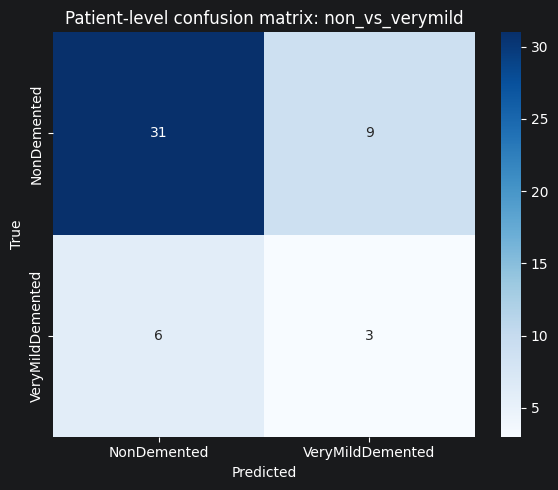

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, recall_score

test_metrics, test_patient_ids, y_true, y_prob, y_pred = evaluate_patient_level(test_loader)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
specificity = cm[0, 0] / max(cm[0].sum(), 1)
sensitivity = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

print(f"TASK: {TASK_NAME}")
print(f"Test patients: {len(y_true)}")
print(f"Accuracy   : {test_metrics['accuracy']:.4f}")
print(f"F1         : {test_metrics['f1']:.4f}")
print(f"Macro F1   : {test_metrics['macro_f1']:.4f}")
print(f"AUROC      : {test_metrics['auroc']:.4f}")
print(f"AUPRC      : {test_metrics['auprc']:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print("\nClassification report")
print(classification_report(
    y_true, y_pred,
    target_names=[TASK["negative_name"], TASK["positive_name"]],
    digits=4,
    zero_division=0,
))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[TASK["negative_name"], TASK["positive_name"]],
    yticklabels=[TASK["negative_name"], TASK["positive_name"]],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Patient-level confusion matrix: {TASK_NAME}")
plt.tight_layout()
plt.show()

## 9. 다음 실험

기본 조기 탐지 결과를 확인한 뒤 `TASK_NAME`만 바꿔 동일한 환자 단위 파이프라인을 실행합니다.

```python
TASK_NAME = "non_vs_verymild"
TASK_NAME = "non_vs_mild"
TASK_NAME = "non_vs_demented"
TASK_NAME = "verymild_vs_advanced"
```

각 task는 별도 kernel restart 후 위에서 아래로 실행하는 것을 권장합니다. Moderate 환자는 2명뿐이므로 Moderate 단독 모델의 성능은 신뢰성 있게 평가할 수 없습니다.